In [1]:
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline
import numpy as np
from UTILS import Verlet_Update, InitialCondition
from scipy.stats import maxwell

# Costants

In [2]:
class constants:
    mass = 1.6735575e-27 # kg, mass Hbar
    bohr_magneton = 9.2740100657e-24 # J/T, CODATA 2022
    kB = 1.380649e-23   # J/K
    Temperature = 10e-3 # K
    Temperature_transv = 5e-3 # K
    harmonic_degree = 2 # degree of the harmonic potential
    harmonic_coefficient = 10 # coefficient harmonic potential
    Zmin = -0.605 # m
    Zmax = -0.481 # m
    Zmid = -0.544 # m
    zacceptance_min = -0.775
    zacceptance_max = -0.325
    mu_eff_over_m = .5 * bohr_magneton / mass

CONSTANTS = constants()

# Functions to make the plot nicer

In [3]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

# Boltzmann-Maxwell distribution

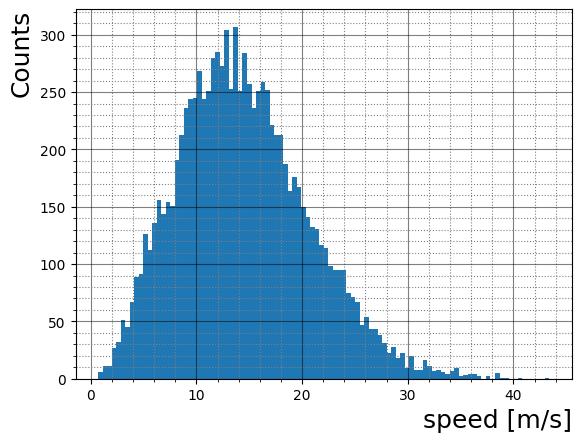

In [4]:
scale = np.sqrt(CONSTANTS.kB * CONSTANTS.Temperature/CONSTANTS.mass)
sampling = maxwell.rvs(scale = scale, size = 10000)
plt.hist(sampling, bins = 100)
plotter_nicer("speed [m/s]", "Counts")

In [5]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000

print(type(data))
print(10*"-")
print(data)
print(10*"-")
print(data[0])
print(10*"-")
print(data[0][0], data[0][1] )
print(10*"-")
print(data["z_mm__Min_B_on_wall"])
#Z, Potential, Z_minwall, PotentialMinWall 

<class 'numpy.ndarray'>
----------
[(-3000., -0.00466533, -1000. , 0.779155)
 (-2997., -0.00465643,  -999.5, 0.780256)
 (-2994., -0.0046475 ,  -999. , 0.781354) ...
 ( 2994.,  0.00595184,     nan,      nan)
 ( 2997.,  0.00595344,     nan,      nan)
 ( 3000.,  0.00595506,     nan,      nan)]
----------
(-3000., -0.00466533, -1000., 0.779155)
----------
-3000.0 -0.00466533
----------
[-1000.   -999.5  -999.  ...     nan     nan     nan]


## Plot of the Magnetic field profile, 17mT well

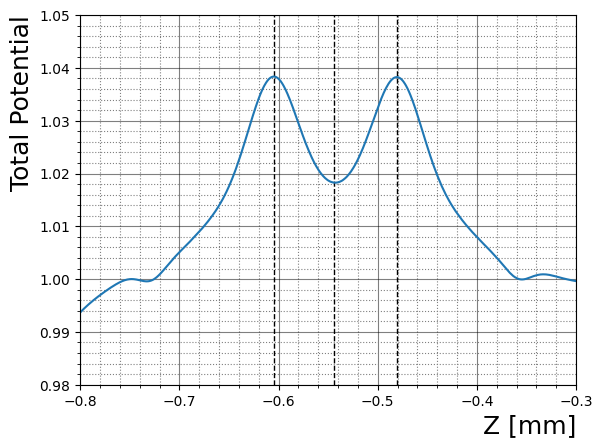

In [6]:
plotter_nicer("Z [mm]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)
plt.axvline(-0.605, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.544, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-0.481, linestyle = "--", color = "black", linewidth = 1)
plt.plot(data['\ufeffz_mm__Bz_on_axis']/1000,data["Total_potential_T__Bz_on_axis"] )

## Spline Creation

- **Bfield(x)** Magnetic Field Potential

In [7]:
Z = data['\ufeffz_mm__Bz_on_axis']/1000
print(Z)
Uz = data["Total_potential_T__Bz_on_axis"]
Bfield = CubicSpline(Z, Uz)

[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ]


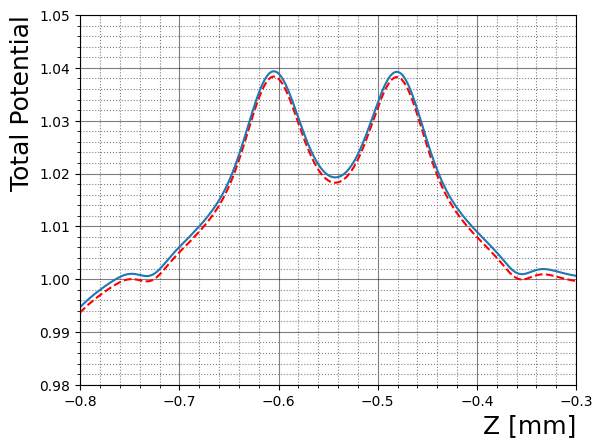

In [8]:
plotter_nicer("Z [mm]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)

plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.plot(Z,data["Total_potential_T__Bz_on_axis"] + 0.001 )

# Energy Distribution

In [9]:
from scipy.optimize import brentq

<ErrorbarContainer object of 3 artists>

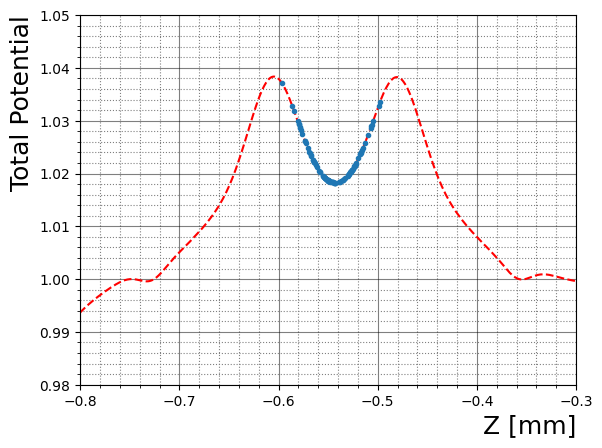

In [10]:
nAtoms = 100

Zinit = [InitialCondition(Bfield, CONSTANTS)[1] for i in range(0,nAtoms)]

plotter_nicer("Z [mm]", "Total Potential")
plt.xlim(-0.800, -0.300)
plt.ylim(0.98, 1.05)
plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.errorbar(Zinit, Bfield(Zinit), linestyle = "", marker = ".")

[  5.82306184   7.42761351   8.85542727 ...   7.49651379   9.40737312
 -10.36289749]


(array([319., 518., 641., 731., 733., 701., 553., 459., 271.,  91.,  92.,
        259., 465., 623., 682., 720., 687., 643., 552., 260.]),
 array([-10.47530952,  -9.42575626,  -8.376203  ,  -7.32664973,
         -6.27709647,  -5.22754321,  -4.17798994,  -3.12843668,
         -2.07888342,  -1.02933015,   0.02022311,   1.06977637,
          2.11932964,   3.1688829 ,   4.21843616,   5.26798943,
          6.31754269,   7.36709595,   8.41664922,   9.46620248,
         10.51575575]),
 <BarContainer object of 20 artists>)

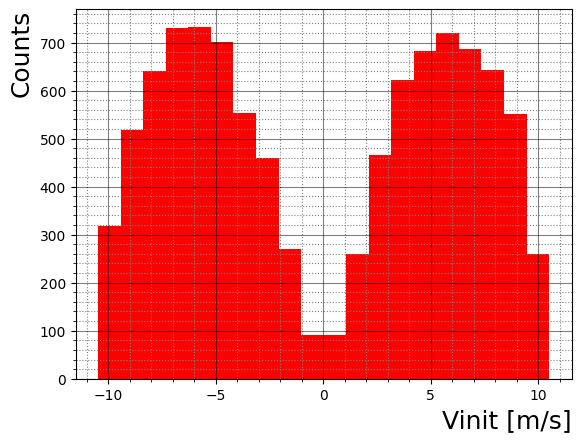

In [11]:
nAtoms = 10000

Vinit = np.array([InitialCondition(Bfield, CONSTANTS)[0] for i in range(0,nAtoms)]).flatten()
print(Vinit)
plotter_nicer("Vinit [m/s]", "Counts")
plt.hist(Vinit, bins = 20, linestyle = "--", color = "red")

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')

# fig, ax = plt.subplots()
# x = np.linspace(0, 2*np.pi, 200)
# pt, = ax.plot([], [], 'o')
# ax.set_xlim(0, 2*np.pi)
# ax.set_ylim(-1.2, 1.2)

# def init():
#     pt.set_data([], [])
#     return (pt,)

# def update(i):
#     t = i/30
#     pt.set_data([t%(2*np.pi)], [np.sin(t)])
#     return (pt,)

# ani = FuncAnimation(fig, update, init_func=init, frames=300, interval=20, blit=True)
# plt.close(fig)
# HTML(ani.to_jshtml())

# Testing 3d code

In [13]:
from UTILS import Gradient_Computation_1d, dB_seg

In [14]:
data = np.genfromtxt("Bfield/PreGravity_20mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_20mT_pregravity = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_17mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_17mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_5mT = CubicSpline(Z, Uz)

data = np.genfromtxt("Bfield/GravityRelease_2p5mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )
Z = data['\ufeffz_mm__Bz_on_axis']/1000
Uz = data["Total_potential_T__Bz_on_axis"]
print(Z, Uz)
Bfield_2p5mT = CubicSpline(Z, Uz)

[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466533 -0.00465643 -0.0046475  ...  0.00595184  0.00595344
  0.00595506]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466541 -0.0046565  -0.00464758 ...  0.00595181  0.00595341
  0.00595504]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466567 -0.00465677 -0.00464784 ...  0.00595172  0.00595332
  0.00595495]
[-3.    -2.997 -2.994 ...  2.994  2.997  3.   ] [-0.00466573 -0.00465683 -0.0046479  ...  0.00595171  0.00595331
  0.00595493]


## Create Magnetic field and Gradient Grid

In [15]:
zgrid = np.linspace(-0.800, -0.300, 100000)   # half mm of discretization 
z0 = zgrid[0]
dz = np.diff(zgrid)[0]

dBfield_20mT_pregravity_dz  = np.array(Gradient_Computation_1d(Bfield_20mT_pregravity, zgrid))
Bfield_20mT_pregravity_grid = np.array(Bfield_20mT_pregravity(zgrid))

dBfield_17mT_dz             = np.array(Gradient_Computation_1d(Bfield_17mT, zgrid))
Bfield_17mT_grid            = np.array(Bfield_17mT(zgrid))

dBfield_5mT_dz              = np.array(Gradient_Computation_1d(Bfield_5mT, zgrid))
Bfield_5mT_grid             = np.array(Bfield_5mT(zgrid))

dBfield_2p5mT_dz            = np.array(Gradient_Computation_1d(Bfield_2p5mT, zgrid))
Bfield_2p5mT_grid           = np.array(Bfield_2p5mT(zgrid))

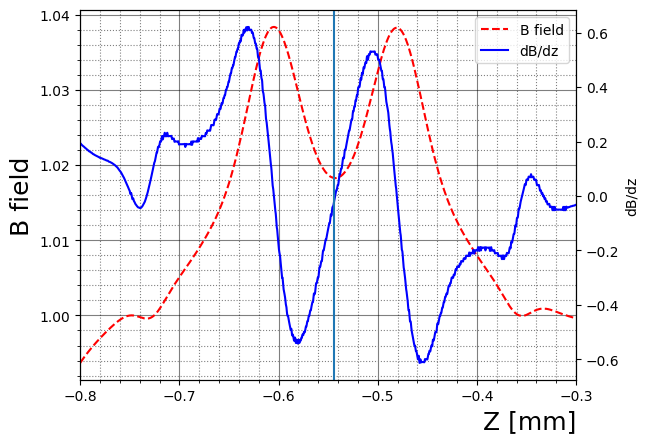

In [16]:
fig, ax1 = plt.subplots()

plotter_nicer("Z [mm]", "Total Potential")
ax1.set_xlim(-0.800, -0.300)

# Primo asse y (ad esempio per il potenziale)
ax1.plot(zgrid, Bfield_20mT_pregravity_grid, linestyle="--", color="red", label="B field")

# Secondo asse y per la derivata
ax2 = ax1.twinx()
ax2.plot(zgrid, dBfield_20mT_pregravity_dz, color="blue", label="dB/dz")
ax2.axvline(CONSTANTS.Zmid)

# Etichette
ax1.set_ylabel("B field")
ax2.set_ylabel("dB/dz")

# Se vuoi una legenda combinata:
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

In [17]:
# dB_seg(z, x, y, 
#        Tloc, ramplength, 
#        z0, dz, 
#        dBinit,
#        Binit,
#        dBfinal,
#        Bfinal):

In [18]:
a = dB_seg(CONSTANTS.Zmid,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

a = dB_seg(-0.51,0,0,
       0,10,
       z0, dz,
       dBfield_20mT_pregravity_dz,
       Bfield_20mT_pregravity_grid,
       dBfield_17mT_dz,
       Bfield_17mT_grid)
print(f"[{a[0]},{a[1]},{a[2]}]")

[0.0,0.0,-0.020046594784606242]
[0.0,0.0,0.5000035095563682]


## Test 3d Initial Conditions

In [19]:
from UTILS import InitialCondition_3d

In [20]:
# Initialize the particles
Z_array = []
X_array = []
Y_array = []
V_array = []
Time_Annihilation = []
Annihilation      = []
for _ in range(nAtoms):
    #print("Extracting values:")
    Vinit, Rinit = InitialCondition_3d(Bfield_20mT_pregravity, CONSTANTS) # Define initial conditions of the simulation
    # Initial position
    Z_array.append(Rinit[0])
    X_array.append(Rinit[1])
    Y_array.append(Rinit[2])
    
    V_array.append(Vinit)             # Initial speed
    Time_Annihilation.append(np.nan)  # Time annihilation
    Annihilation.append(False)        # Annihilation bool array

Z_array = np.array(Z_array).flatten()
V_array = np.array(V_array)
print(V_array.shape)

Time_Annihilation = np.array(Time_Annihilation).flatten()
Annihilation = np.array(Annihilation).flatten()

(10000, 3)


(array([0.000e+00, 1.000e+00, 1.300e+01, 4.800e+01, 1.410e+02, 3.750e+02,
        7.410e+02, 1.086e+03, 1.307e+03, 1.242e+03, 1.190e+03, 1.345e+03,
        1.088e+03, 8.090e+02, 4.020e+02, 1.530e+02, 4.600e+01, 9.000e+00,
        3.000e+00, 1.000e+00]),
 array([-30., -27., -24., -21., -18., -15., -12.,  -9.,  -6.,  -3.,   0.,
          3.,   6.,   9.,  12.,  15.,  18.,  21.,  24.,  27.,  30.]),
 <BarContainer object of 20 artists>)

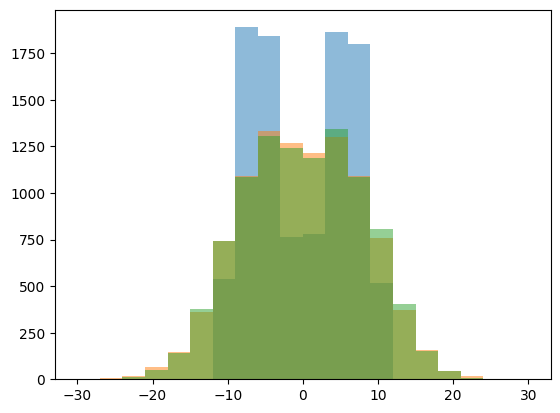

In [21]:
plt.hist(V_array[:,0], range = (-30, 30), bins = 20, alpha = .5)
plt.hist(V_array[:,1], range = (-30, 30), bins = 20, alpha = .5)
plt.hist(V_array[:,2], range = (-30, 30), bins = 20, alpha = .5)